In [2]:
import numpy as np
import matplotlib.pyplot as plt

import keras

# Load the MNIST dataset
from keras.datasets import mnist

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense , Dropout

# Preprocessing

In this section, we load and preprocess the MNIST dataset. The dataset consists of 28×28 pixel grayscale images of handwritten digits (0-9).

## Steps:
1. **Load the data**: Split into training and testing sets
2. **Normalize pixel values**: Scale to [0, 1] range
3. **Flatten images**: Convert 28×28 matrices to 1D vectors (optional, depending on model architecture)
4. **One-hot encode labels**: Convert digit labels to categorical format

This preprocessing ensures the data is in the correct format for training a neural network model.

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
def plot_input_image(i):
    plt.figure(figsize=(2,2))
    plt.imshow(X_train[i], cmap='binary')
    plt.title(y_train[i])
    plt.axis('off')
    plt.show()
    

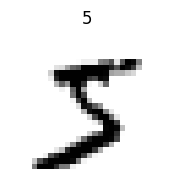

None


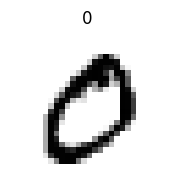

None


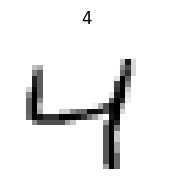

None


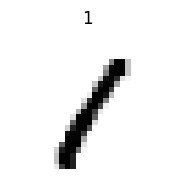

None


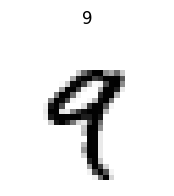

None


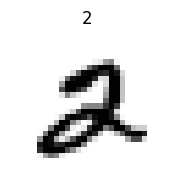

None


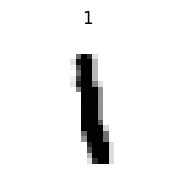

None


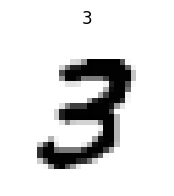

None


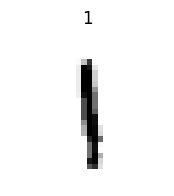

None


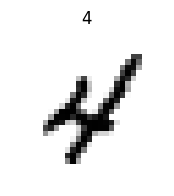

None


In [5]:
for i in range(10):
    print(plot_input_image(i))

In [6]:
#preprocessing the data

#Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = np.expand_dims(X_train, -1) # (60000, 28, 28, 1)
X_test = np.expand_dims(X_test, -1) # (10000, 28, 28, 1)

In [7]:
keras.utils.to_categorical(y_train).shape

keras.utils.to_categorical(y_test).shape

(10000, 10)

In [8]:
y_train[:10], y_test[:10]

(array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8),
 array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8))

In [9]:
model =Sequential()

model.add(Conv2D(32, (3,3), input_shape=(28,28,1), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dropout(0.25))

model.add(Dense(10, activation='softmax'))

c:\Users\Aditya\code_hub\Hand_written_Digit_recognization\.env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam', loss=keras.losses.sparse_categorical_crossentropy, metrics=['accuracy'])

In [12]:
#callbacks
from keras.callbacks import EarlyStopping , ModelCheckpoint

#Early stopping
es= early_stopping = EarlyStopping(monitor='val_loss', patience=4, min_delta=0.001,  verbose=1)

#Model checkpoint
mc = model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', verbose=1)

cb = [es, mc]

In [13]:
history = model.fit(X_train, y_train, epochs=50, batch_size=128, validation_split=0.3, callbacks=cb)

Epoch 1/50
323/329 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7704 - loss: 0.8100
Epoch 1: saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8910 - loss: 0.3815 - val_accuracy: 0.9659 - val_loss: 0.1150
Epoch 2/50
323/329 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9642 - loss: 0.1166
Epoch 2: saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9677 - loss: 0.1070 - val_accuracy: 0.9762 - val_loss: 0.0822
Epoch 3/50
326/329 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9763 - loss: 0.0790
Epoch 3: saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9761 - loss: 0.0776 - val_accuracy: 0.9806 - val_loss: 0.0625
Epoch 4/50
325/329 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.0620
Epoch 4: saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9810 - loss: 0.0617 - val_accuracy: 0.9833 - val_loss: 0.0548
Epoch 5/50
327/329 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9836 - loss: 0.0512
Epoch 5: saving model to best_model.h5


...

329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9907 - loss: 0.0294 - val_accuracy: 0.9879 - val_loss: 0.0392
Epoch 12/50
324/329 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9924 - loss: 0.0241
Epoch 12: saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9918 - loss: 0.0249 - val_accuracy: 0.9879 - val_loss: 0.0412
Epoch 13/50
325/329 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9926 - loss: 0.0241
Epoch 13: saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9921 - loss: 0.0244 - val_accuracy: 0.9875 - val_loss: 0.0419
Epoch 14/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9934 - loss: 0.0203
Epoch 14: saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9923 - loss: 0.0233 - val_accuracy: 0.9879 - val_loss: 0.0429
Epoch 15/50
326/329 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9934 - loss: 0.0205
Epoch 15: saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9928 - loss: 0.0214 - val_accuracy: 0.9880 - val_loss: 0.0420
Epoch 15: early stopping


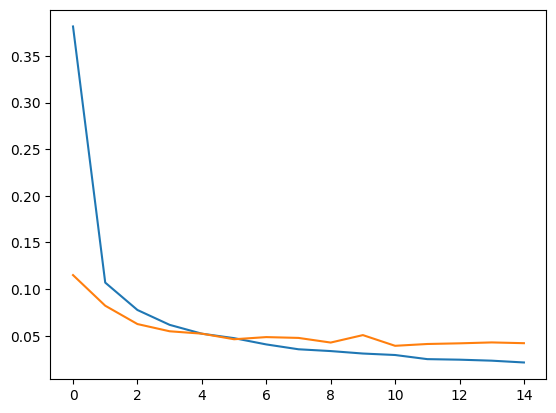

In [14]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

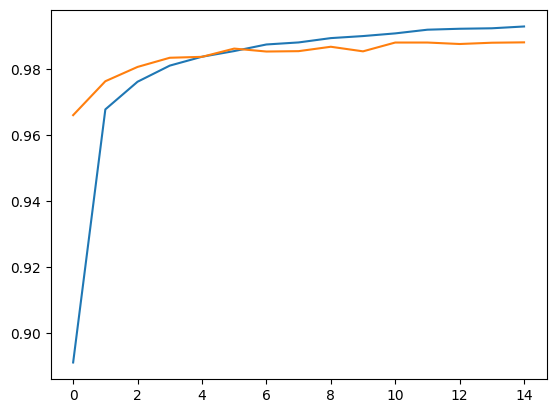

In [15]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')